# 💡 **Nota Bene:** I will use GPU, not CPU

In [53]:
#@title Step 0: Check GPU Status
import subprocess
simple_nvidia_smi_display = True#@param {type:"boolean"}
if simple_nvidia_smi_display:
    #!nvidia-smi
    nvidiasmi_output = subprocess.run(['nvidia-smi', '-L'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
else:
    #!nvidia-smi -i 0 -e 0
    nvidiasmi_output = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
    nvidiasmi_ecc_note = subprocess.run(['nvidia-smi', '-i', '0', '-e', '0'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_ecc_note)

GPU 0: Tesla T4 (UUID: GPU-f83c2f80-46b0-6d04-01d9-6eff5c7724c3)



In [54]:
#@title Step 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns # for hot msp
import kagglehub # for kaggle code in dataset https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset?resource=download

# 💡 **Nota Bene:**  I will try code from Kaggle:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")

print("Path to dataset files:", path)

In [55]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")

#print("Path to dataset files:", path)

In [56]:
#@title Step 2: Load this Ames Housing dataset into memory

df = pd.read_csv('AmesHousing.csv')
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [57]:
#@title  Step 3: Split data into training set (70%) and testing set (30%)
# We use random_state to get the same split every time
train_data, test_data = train_test_split(df, test_size=0.30, random_state=42)


--- Check Dataset Split ---
Original data shape: (2930, 82)
Training data shape (70%): (2051, 82)
Testing data shape (30%): (879, 82)




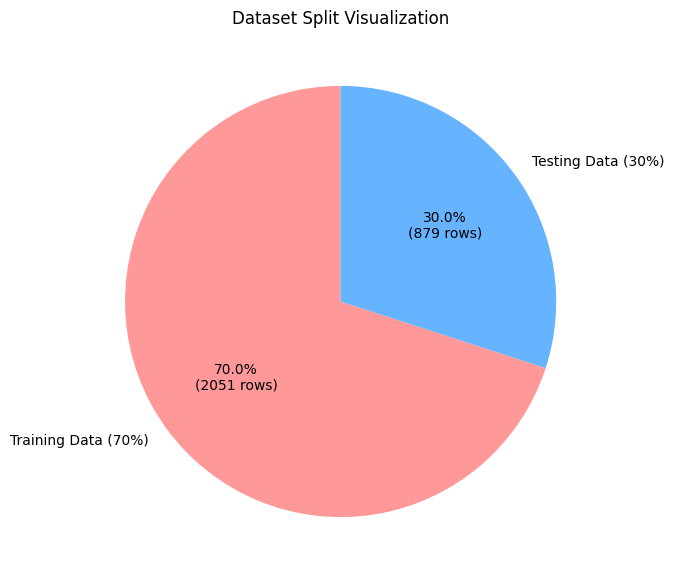

In [58]:
#@title  Step 4: Print sizes
print("--- Check Dataset Split ---")
print("Original data shape:", df.shape)
print("Training data shape (70%):", train_data.shape)
print("Testing data shape (30%):", test_data.shape)
print("\n")

# Data for plotting
labels = ['Training Data (70%)', 'Testing Data (30%)']
counts = [len(train_data), len(test_data)]
colors = ['#ff9999', '#66b3ff']

# Function to display count and percentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.1f}%\n({v:d} rows)'.format(p=pct, v=val)
    return my_autopct

# Create a pie chart
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct=make_autopct(counts), startangle=90, colors=colors)
plt.title('Dataset Split Visualization')
plt.show()

# 💡 **Nota Bene:**: I see a 30/70 split.
Also, this training set of over 2000.

In [59]:
#@title  Step 5: Find columns with missing values (NaN) only in training data
# Testing data must stay untouched
missing_values = train_data.isnull().sum()
missing_cols = missing_values[missing_values > 0].sort_values(ascending=False)

print("--- Columns with Missing Values in Train Data ---")
if not missing_cols.empty:
    for col, count in missing_cols.items():
        print(f"Column: {col} | Missing cells: {count} | Type: {train_data[col].dtype}")
else:
    print("No missing values found in this training dataset.")

--- Columns with Missing Values in Train Data ---
Column: Pool QC | Missing cells: 2041 | Type: object
Column: Misc Feature | Missing cells: 1969 | Type: object
Column: Alley | Missing cells: 1904 | Type: object
Column: Fence | Missing cells: 1642 | Type: object
Column: Mas Vnr Type | Missing cells: 1246 | Type: object
Column: Fireplace Qu | Missing cells: 1016 | Type: object
Column: Lot Frontage | Missing cells: 347 | Type: float64
Column: Garage Cond | Missing cells: 111 | Type: object
Column: Garage Yr Blt | Missing cells: 111 | Type: float64
Column: Garage Finish | Missing cells: 111 | Type: object
Column: Garage Qual | Missing cells: 111 | Type: object
Column: Garage Type | Missing cells: 109 | Type: object
Column: Bsmt Exposure | Missing cells: 55 | Type: object
Column: BsmtFin Type 2 | Missing cells: 54 | Type: object
Column: Bsmt Qual | Missing cells: 53 | Type: object
Column: BsmtFin Type 1 | Missing cells: 53 | Type: object
Column: Bsmt Cond | Missing cells: 53 | Type: object

# 💡 **Nota Bene:**:  I don't analyze the test data, because, as far as our model is concerned, it doesn't exist yet

Before step 6:

In [60]:
print(train_data['Alley'].value_counts(dropna=False))

Alley
NaN     1904
Grvl      90
Pave      57
Name: count, dtype: int64


In [61]:
#@title Step 6: Fill NaN values using logical categories
# We make one copy to avoid pandas warnings
train_data = train_data.copy()

# Category 1: Missing text means this house does not have this feature (e.g., no pool, no alley)
cols_none = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu',
             'Garage Cond', 'Garage Finish', 'Garage Qual', 'Garage Type',
             'Bsmt Exposure', 'BsmtFin Type 2', 'Bsmt Qual', 'BsmtFin Type 1', 'Bsmt Cond']

for col in cols_none:
    train_data[col] = train_data[col].fillna('None')

# Category 2: Missing number means zero area or zero cars
cols_zero = ['Garage Yr Blt', 'Mas Vnr Area', 'BsmtFin SF 1', 'Bsmt Half Bath',
             'Total Bsmt SF', 'Bsmt Full Bath', 'BsmtFin SF 2', 'Bsmt Unf SF',
             'Garage Area', 'Garage Cars']

for col in cols_zero:
    train_data[col] = train_data[col].fillna(0)

print("--- Check Empty Cells after Step 6 ---")
print("Remaining NaN count:", train_data[cols_none + cols_zero].isnull().sum().sum())

--- Check Empty Cells after Step 6 ---
Remaining NaN count: 0


After step 6:

In [62]:
print(train_data['Alley'].value_counts(dropna=False))

Alley
None    1904
Grvl      90
Pave      57
Name: count, dtype: int64


# 💡 **Nota Bene:**: NaN 1904 -> None 1904

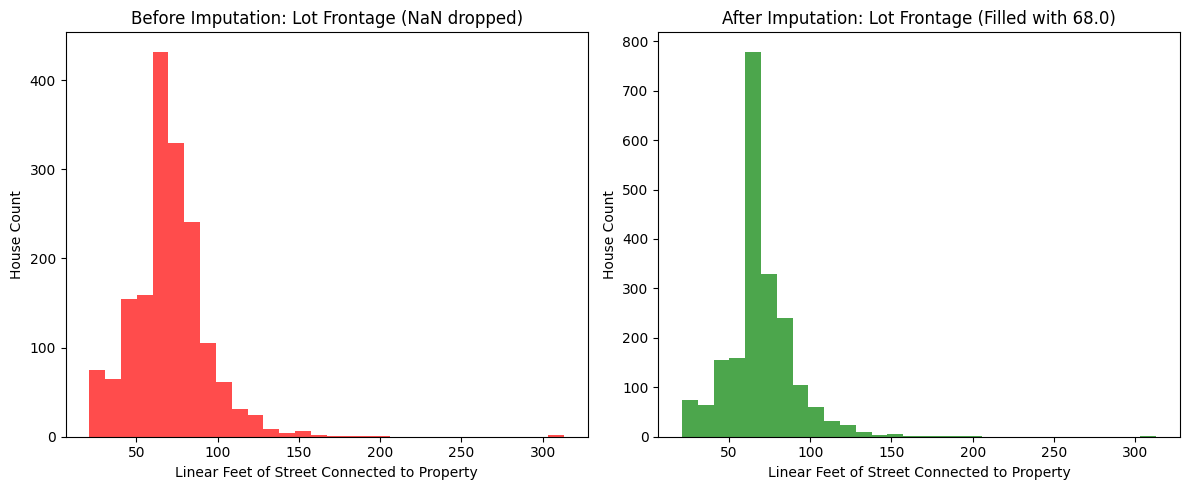

--- Check Lot Frontage Data ---
2210    82.0
782     65.0
2310    60.0
299     35.0
2423    68.0
Name: Lot Frontage, dtype: float64


In [63]:
#@title Step 7: Fill missing values with Median and plot with Matplotlib

# Save old data to plot "Before"
lot_frontage_before = train_data['Lot Frontage'].copy()

# Category 3: Fill missing physical measurements with median number
median_value = train_data['Lot Frontage'].median()
train_data['Lot Frontage'] = train_data['Lot Frontage'].fillna(median_value)

# Save new data to plot "After"
lot_frontage_after = train_data['Lot Frontage']

# Build Matplotlib plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Before
axes[0].hist(lot_frontage_before.dropna(), bins=30, color='red', alpha=0.7)
axes[0].set_title('Before Imputation: Lot Frontage (NaN dropped)')
axes[0].set_xlabel('Linear Feet of Street Connected to Property')
axes[0].set_ylabel('House Count')

# Plot 2: After
axes[1].hist(lot_frontage_after, bins=30, color='green', alpha=0.7)
axes[1].set_title(f'After Imputation: Lot Frontage (Filled with {median_value})')
axes[1].set_xlabel('Linear Feet of Street Connected to Property')
axes[1].set_ylabel('House Count')

plt.tight_layout()
plt.show()

# Print sample data
print("--- Check Lot Frontage Data ---")
print(train_data['Lot Frontage'].head())

# 💡 **Nota Bene:**:  The median is better than the average because it ignores very high outliers.

In [64]:
#@title Step 8: Feature Engineering and Encoding
# Create new feature: House Age
train_data['House_Age'] = train_data['Yr Sold'] - train_data['Year Built']

# Convert text categories to numbers (Simple One-Hot Encoding example)
# We choose a few important text columns to encode
train_data = pd.get_dummies(train_data, columns=['Street', 'Central Air'], drop_first=True)

# Encoding Ordinal data (Mapping quality text to numbers)
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
train_data['Exter Qual'] = train_data['Exter Qual'].map(qual_map)

print("--- Feature Engineering & Encoding Complete ---")
print("New columns:", train_data.columns[-5:].tolist())

--- Feature Engineering & Encoding Complete ---
New columns: ['Sale Condition', 'SalePrice', 'House_Age', 'Street_Pave', 'Central Air_Y']


In [65]:
train_data

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Alley,Lot Shape,Land Contour,Utilities,...,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,House_Age,Street_Pave,Central Air_Y
2210,2211,909275030,90,RH,82.0,6270,None,Reg,HLS,AllPub,...,None,0,8,2007,WD,Normal,145000,58,True,False
782,783,905325020,20,RL,65.0,25095,None,IR1,Low,AllPub,...,None,0,6,2009,WD,Partial,143000,41,True,True
2310,2311,527105060,60,RL,60.0,8238,None,IR1,Lvl,AllPub,...,None,0,5,2006,WD,Normal,183500,9,True,True
299,300,909455040,120,RM,35.0,3907,None,IR1,HLS,AllPub,...,None,0,3,2010,WD,Normal,162500,21,True,True
2423,2424,528228415,120,RM,68.0,3072,None,Reg,Lvl,AllPub,...,None,0,5,2006,WD,Normal,178740,2,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1639,527226040,190,RL,195.0,41600,None,IR1,Lvl,AllPub,...,None,0,11,2007,WD,Normal,155000,38,True,True
1095,1096,528290090,60,RL,68.0,7750,None,Reg,Lvl,AllPub,...,None,0,4,2008,WD,Normal,176000,6,True,True
1130,1131,528490080,60,FV,64.0,8791,None,IR1,Lvl,AllPub,...,None,0,5,2008,WD,Normal,207500,5,True,True
1294,1295,902109160,50,RM,81.0,7308,None,Reg,Lvl,AllPub,...,None,0,6,2008,WD,Normal,122250,88,True,False


In [66]:
print(train_data[['Street_Pave', 'Central Air_Y']].head(10))

      Street_Pave  Central Air_Y
2210         True          False
782          True           True
2310         True           True
299          True           True
2423         True           True
1995         True           True
2177         True           True
1562         True           True
2229         True           True
1592         True           True


# 💡 **Nota Bene:**: I'll try using the hot map

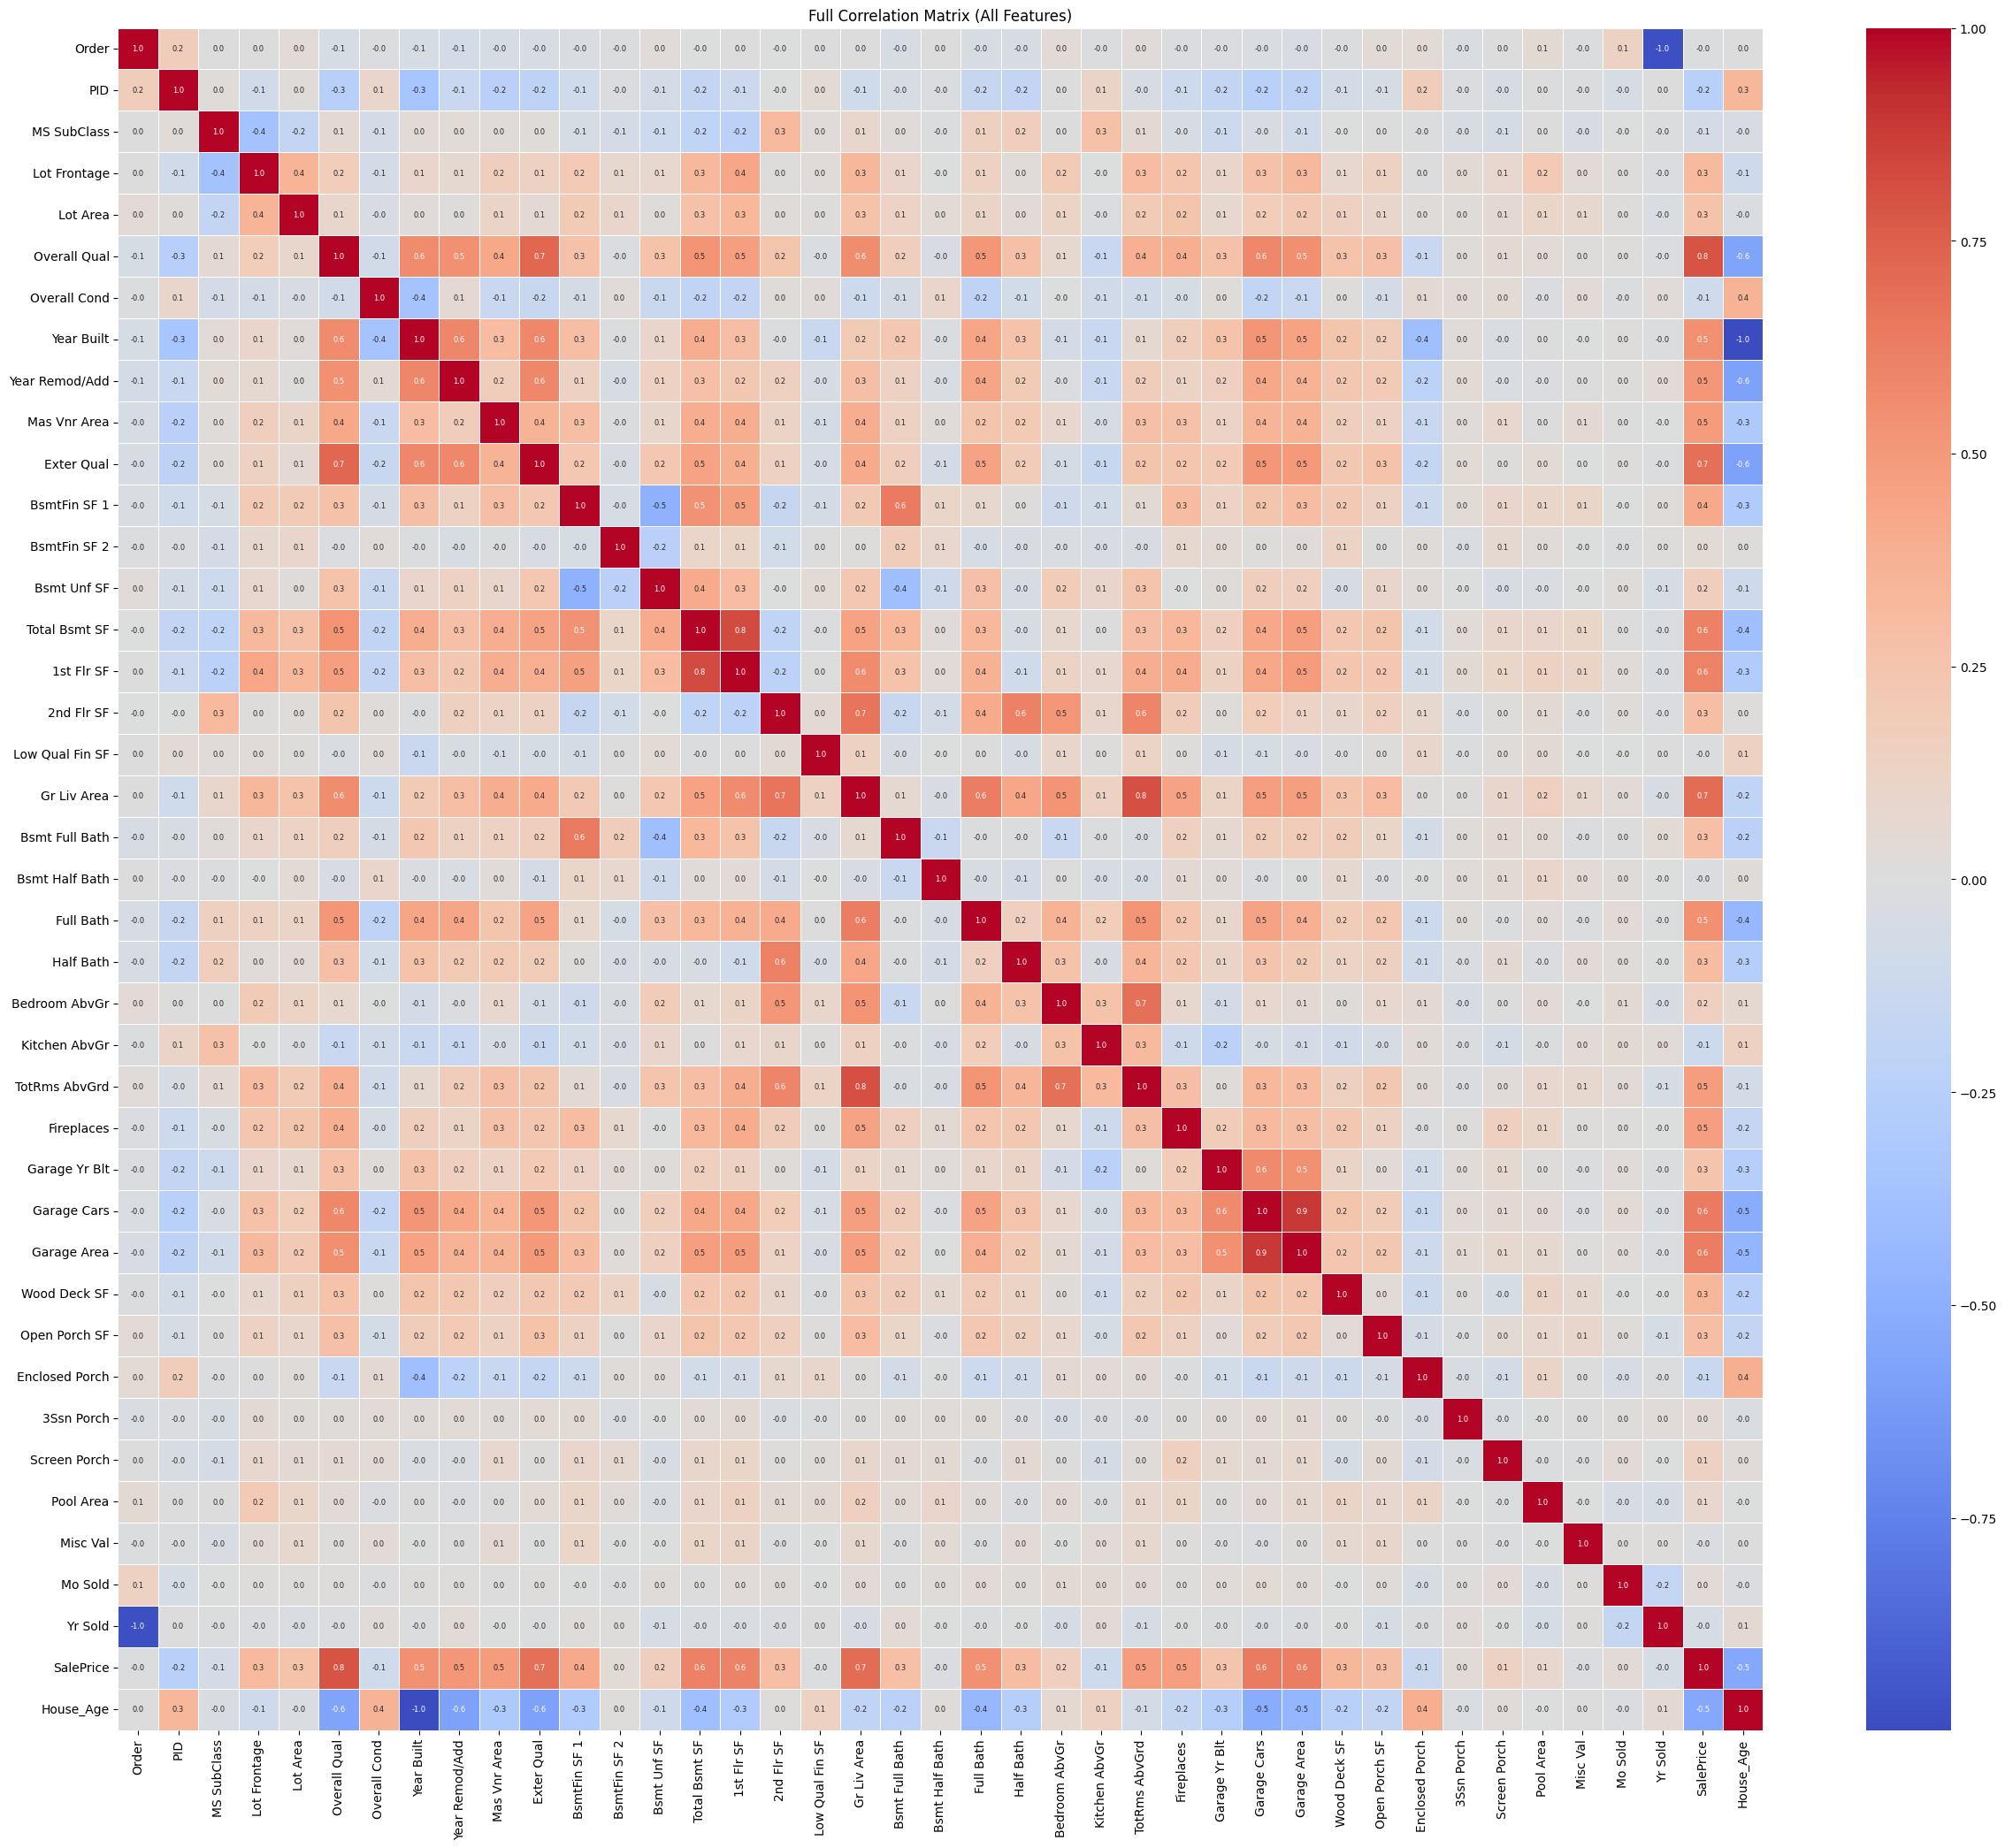

In [67]:
numeric_df = train_data.select_dtypes(include=[np.number])


full_corr = numeric_df.corr()

# Make hot map
plt.figure(figsize=(30, 25))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt=".1f",
            annot_kws={"size": 6}, linewidths=0.5)

plt.title('Full Correlation Matrix (All Features)')
plt.show()

# 💡 **Nota Bene:**:  There's too much data; I'll just include the correlation with price.

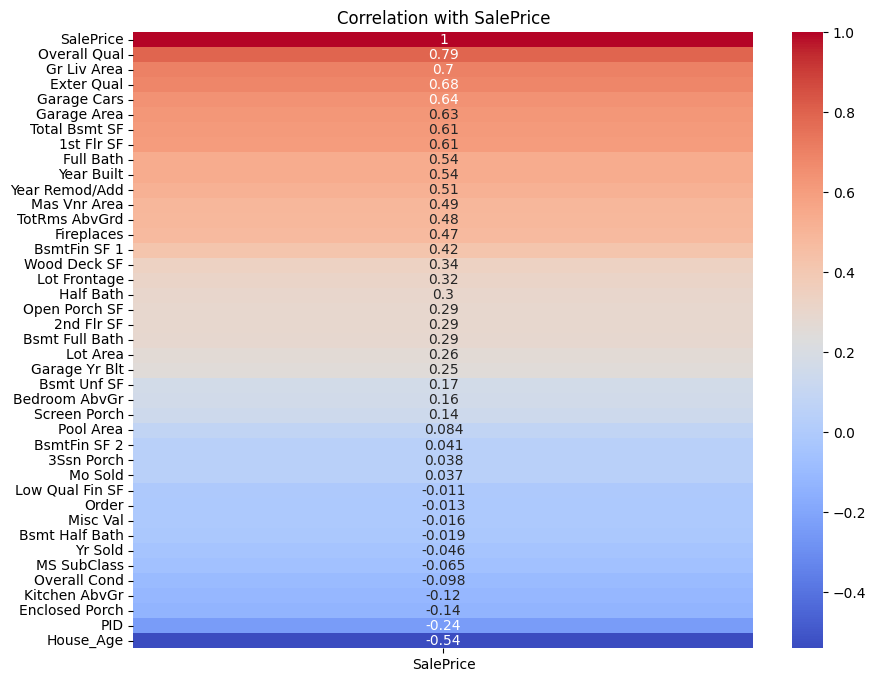

In [68]:
numeric_df = train_data.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr()[['SalePrice']].sort_values(by='SalePrice', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with SalePrice')
plt.show()

In [69]:
#@title Step 9: Normalization, Scaling and Class Balancing
from sklearn.preprocessing import StandardScaler

# Convert boolean to integer (1 and 0) for ML
train_data['Street_Pave'] = train_data['Street_Pave'].astype(int)
train_data['Central Air_Y'] = train_data['Central Air_Y'].astype(int)

# Normalization: Adjust distribution shape for SalePrice (Fix right skew)
train_data['SalePrice_Log'] = np.log1p(train_data['SalePrice'])

# Scaling: Change data range for large area metrics
scaler = StandardScaler()
cols_to_scale = ['Gr Liv Area', 'Lot Area']
train_data[cols_to_scale] = scaler.fit_transform(train_data[cols_to_scale])

# Class Balancing: Convert SalePrice to binary target
median_price = train_data['SalePrice'].median()
train_data['Target'] = (train_data['SalePrice'] > median_price).astype(int)

# Balance classes using Undersampling
premium_houses = train_data[train_data['Target'] == 1]
standard_houses = train_data[train_data['Target'] == 0].sample(n=len(premium_houses), random_state=42)
final_df = pd.concat([premium_houses, standard_houses])

# Export Final Dataset
final_df.to_csv('Ames_Housing_Cleaned.csv', index=False)

print("--- Data Preprocessing Finalized ---")
print("Target Class Distribution:")
print(final_df['Target'].value_counts())

--- Data Preprocessing Finalized ---
Target Class Distribution:
Target
1    1011
0    1011
Name: count, dtype: int64


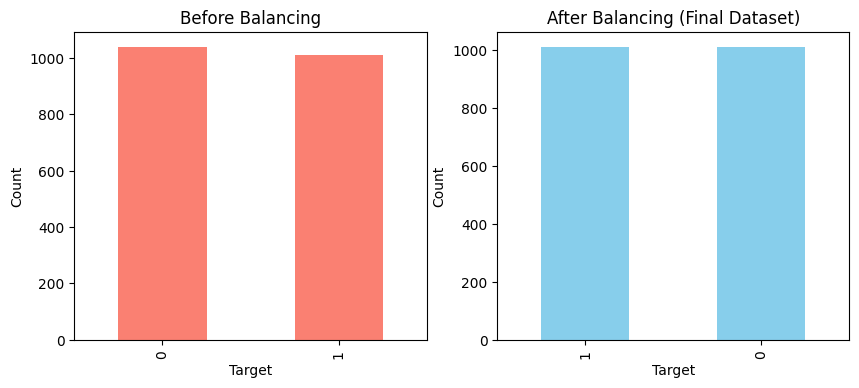

In [70]:
#@title Visualizing Class Balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
train_data['Target'].value_counts().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Before Balancing')
axes[0].set_ylabel('Count')

# After
final_df['Target'].value_counts().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('After Balancing (Final Dataset)')
axes[1].set_ylabel('Count')

plt.show()

# 💡 **Nota Bene:**: I need to see more information

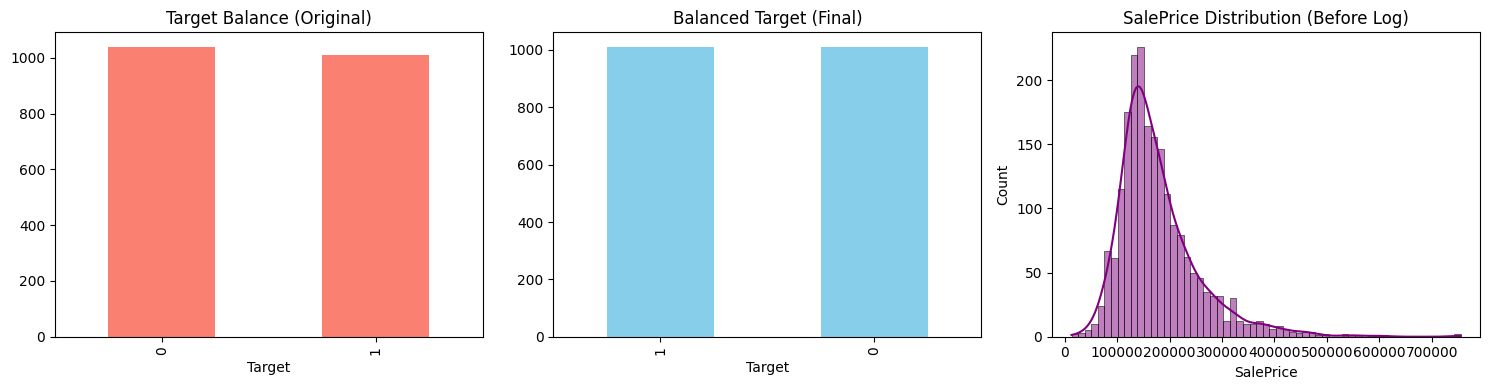

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Target Balance (Before)
train_data['Target'].value_counts().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Target Balance (Original)')

# 2. Final Dataset Balance (After)
final_df['Target'].value_counts().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Balanced Target (Final)')

# 3. SalePrice Distribution
sns.histplot(train_data['SalePrice'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('SalePrice Distribution (Before Log)')

plt.tight_layout()
plt.show()

# 💡 **Nota Bene:** ML Problem Discussion
I will use this clean dataset to solve one classification problem. This dataset has many features like 'House_Age', 'Lot Area', and 'Street_Pave'. I want to build one ML model to predict premium houses.

First, I will change 'SalePrice' into one binary target (Premium or Standard). Next, I will balance these classes. This model can help real estate agents. They can use this model to predict if one new house gets premium status.

# 💡 **Nota Bene:** Final Actions Summary
I used log transform to normalize 'SalePrice' because this distribution had one big right skew. I used StandardScaler to change range for 'Gr Liv Area'. Finally, I created one binary target and balanced these classes with undersampling method. Testing data stays untouched. Clean CSV file is ready for GitHub.